## 1. Dependencies

In [1]:
!pip install -q rdflib langchain-ollama langchain-community langchain-text-splitters chromadb pypdf requests beautifulsoup4 lxml langgraph


## 2. Loading the rdf data as an input knowledge graph

In [2]:
from pathlib import Path
from rdflib import Graph

_HERE = Path(__file__).parent if "__file__" in dir() else Path.cwd()
g = Graph()
g.parse(str(Path.home() / "Desktop" / "emdat_climate_events27.ttl"), format="ttl")
print(f"Loaded {len(g)} triples")


Loaded 73781 triples


## 3. Defining the LLMs for each different task

In [3]:
from langchain_ollama import ChatOllama

# Main model — KG exploration, SPARQL querying, synthesis, feedback
llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=0.5, num_ctx=4096)

# Router — lightweight classifier, no tools
llm_router = ChatOllama(model="llama3.1:8b", temperature=0, num_ctx=4096)

# RAG model — semantic search distillation
llm_rag_model = ChatOllama(model="gpt-oss:120b-cloud", temperature=0, num_ctx=4096)


## 5. Defining the tools as functions

In [4]:
from langchain.tools import tool

# ── KG exploration tools ───────────────────────────────────────────────────

@tool
def list_classes(limit: int = 50) -> list:
    """Return RDF classes used in the knowledge graph."""
    results = g.query(f"SELECT DISTINCT ?c WHERE {{ ?s rdf:type ?c }} LIMIT {limit}")
    return [str(r[0]) for r in results]

@tool
def list_predicates(limit: int = 50) -> list:
    """Return predicates present in the knowledge graph."""
    results = g.query(f"SELECT DISTINCT ?p WHERE {{ ?s ?p ?o }} LIMIT {limit}")
    return [str(r.p) for r in results]

@tool
def get_class_properties(class_name: str) -> list:
    """Return predicates used by instances of a given class (e.g. 'ssn:Observation')."""
    cn = f"<{class_name}>" if class_name.startswith("http") else class_name
    results = g.query(f"SELECT DISTINCT ?p WHERE {{ ?s rdf:type {cn} ; ?p ?o }}")
    return [str(r.p) for r in results]

@tool
def sample_instances(class_name: str, limit: int = 10) -> list:
    """Return sample instance URIs for a given class."""
    cn = f"<{class_name}>" if class_name.startswith("http") else class_name
    results = g.query(f"SELECT DISTINCT ?s WHERE {{ ?s rdf:type {cn} }} LIMIT {limit}")
    return [str(r.s) for r in results]

@tool
def describe_entity(entity_uri: str) -> list:
    """Return all predicate-object pairs for a given entity URI."""
    results = g.query(f"SELECT ?p ?o WHERE {{ <{entity_uri}> ?p ?o }} LIMIT 50")
    return [{"predicate": str(r.p), "object": str(r.o)} for r in results]

# ── SPARQL execution tool ──────────────────────────────────────────────────

@tool
def run_sparql(query: str) -> list:
    """Execute a SPARQL SELECT query against the knowledge graph."""
    try:
        return [dict(row.asdict()) for row in g.query(query)]
    except Exception as e:
        return [{"error": str(e)}]


## 6. State, system prompts and tool bindings

In [5]:
from typing import Literal
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

_RDF_SCHEMA = """
Allowed prefixes:
@prefix aemet: <http://aemet.linkeddata.es/ontology/> .
@prefix clasik: <https://example.org/clasik#> .
@prefix geo1: <http://www.w3.org/2003/01/geo/wgs84_pos#> .
@prefix gn: <http://www.geonames.org/ontology#> .
@prefix qudt: <http://qudt.org/schema/qudt/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix sorelsc: <http://sweetontology.net/relaSci/> .
@prefix soteria: <https://soteria-public.pages.sintef.no/soteria_ontology_documentation#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

The main node of the knowledge graph is an event, which is an instance of the class clasik:ClimateEvent. 
Each event is linked to a country URI through the gn:locatedIn property, which is described by a string through
the property gn:name. Each event is linked to its provinces through the property clasik:isInProvince. 
Each event is linked to a start date and an end date through the properties soteria:startDate and soteria:endDate.

Each event is related to an impact through the sorelsc:hasImpact property. Each impact 
is characterized as related to deaths through the property clasik:deaths, to people affected through the 
property clasik:peopleAffected, to people injured through the property clasik:injured and 
to economic loss through the property clasik:economicDamage.

Each event is characterized with a Disaster Type through the property clasik:hasDisasterType,
with a Disaster Subtype through the property clasik:hasDisasterSubtype, and with a Disaster
Subgroup with the property clasik:hasDisasterSubgroup.

If a measurement was recorded, an observation could be linked to an event through the aemet:observedProperty, 
and the observation is a quantity value, linked to a string through the property clasik:hasResult. 
"""

# ── Hard call-count limits (enforced in condition functions) ──────────────
MAX_EXPLORE_CALLS = 6   # max tool calls inside kg_explore loop
MAX_QUERY_CALLS   = 4   # max run_sparql attempts inside kg_query loop

KG_EXPLORE_SYS = SystemMessage(content=f"""
You are a KG exploration agent. Tools: list_classes, list_predicates,
get_class_properties, sample_instances, describe_entity.
DO NOT call run_sparql.

IMPORTANT: You have at most {MAX_EXPLORE_CALLS} tool calls total. Be efficient:
  1. list_classes (once)
  2. list_predicates (once)
  3. get_class_properties for the single most relevant class (once)
  4. sample_instances for that class (once)
  5. describe_entity for ONE instance (once)
Stop immediately after step 5 and emit your EXPLORATION SUMMARY — do NOT
repeat any tool unless you got an error. Never call the same tool twice.
{_RDF_SCHEMA}
""")

KG_QUERY_SYS = SystemMessage(content=f"""
You are a SPARQL writer/executor. Only tool: run_sparql.
You have at most {MAX_QUERY_CALLS} attempts. Use the EXPLORATION SUMMARY to
build a correct SELECT query on the first try. If it returns no results,
fix capitalisation/URI patterns and retry — but stop after {MAX_QUERY_CALLS}
attempts regardless. No markdown/backticks in query strings.
Emit a natural-language summary once you have a valid result (or after
exhausting retries, summarise what you found or why the query failed).
{_RDF_SCHEMA}
""")

class AgentState(MessagesState):
    explore_summary: str
    sparql_result:   str
    final_answer:    str
    # ── per-run tool-call counters ──
    explore_call_count: int
    query_call_count:   int

explore_tools = [list_classes, list_predicates, get_class_properties, sample_instances, describe_entity]
query_tools   = [run_sparql]

llm_explore = llm.bind_tools(explore_tools)
llm_query   = llm.bind_tools(query_tools)


## 7. Defining the functions in each graph node

In [6]:
import time
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage, ToolMessage

EXPLORE_HISTORY_WINDOW = 4

def _last_ai(msgs):
    """Most recent non-tool-calling AI message content."""
    return next((m.content for m in reversed(msgs)
                 if isinstance(m, AIMessage) and m.content
                 and not getattr(m, "tool_calls", None)), "")

def _invoke(llm_bound, msgs, retries=3, wait=5):
    """Retry wrapper for transient cloud errors."""
    for i in range(retries):
        try:
            return llm_bound.invoke(msgs)
        except Exception as e:
            if i == retries - 1:
                raise
            print(f"[Retry {i+1}/{retries}] {e} — waiting {wait}s...")
            time.sleep(wait)

# ── KG Explore ────────────────────────────────────────────────────────────

def _direct_tool_call(tool_obj, payload):
    """Call a LangChain tool directly and return either its value or an error string."""
    try:
        return tool_obj.invoke(payload)
    except Exception as e:
        return f"Error: {e}"


def kg_explore_node(state):
    """Deterministic KG exploration.

    This node runs a fixed KG profiling sequence and then asks the LLM only to
    summarize the collected profile for the SPARQL-writing node.
    """
    question = state["messages"][0].content
    classes = _direct_tool_call(list_classes, {"limit": 80})
    predicates = _direct_tool_call(list_predicates, {"limit": 120})
    class_properties = _direct_tool_call(get_class_properties, {"class_name": "clasik:ClimateEvent"})
    sample_events = _direct_tool_call(sample_instances, {"class_name": "clasik:ClimateEvent", "limit": 5})

    described_event = "No event instance available to describe."
    if isinstance(sample_events, list) and sample_events:
        described_event = _direct_tool_call(describe_entity, {"entity_uri": sample_events[0]})

    profile_text = (
        f"Question: {question}\n\n"
        f"CLASSES:\n{classes}\n\n"
        f"PREDICATES:\n{predicates}\n\n"
        f"PROPERTIES OF clasik:ClimateEvent:\n{class_properties}\n\n"
        f"SAMPLE clasik:ClimateEvent INSTANCES:\n{sample_events}\n\n"
        f"DESCRIPTION OF ONE SAMPLE EVENT:\n{described_event}"
    )

    r = _invoke(
        llm,
        [
            SystemMessage(content=(
                "Produce a concise KG exploration summary for a SPARQL writer. "
                "Do not call tools. Focus on useful classes, predicates, URI patterns, "
                "sample entities, and any constraints relevant to the user question."
            )),
            HumanMessage(content=profile_text),
        ],
    )

    new_count = state.get("explore_call_count", 0) + 1
    print(f"[Explore] deterministic profile completed in {new_count} pass(es)")
    return {
        "messages": [r],
        "explore_call_count": new_count,
    }

def kg_explore_condition(state):
    last = state["messages"][-1]
    calls = state.get("explore_call_count", 0)
    if getattr(last, "tool_calls", None) and calls < MAX_EXPLORE_CALLS:
        return "explore_tools"
    if calls >= MAX_EXPLORE_CALLS:
        print(f"[Explore] hit cap ({MAX_EXPLORE_CALLS} calls) — forcing store_explore")
    return "store_explore"

def store_explore_result(state):
    summary = _last_ai(state["messages"])

    if not summary:
        relevant_tools = [
            m for m in state["messages"]
            if isinstance(m, ToolMessage)
            and getattr(m, "name", "") in {
                "list_classes",
                "list_predicates",
                "get_class_properties",
                "sample_instances",
                "describe_entity",
            }
        ]

        if relevant_tools:
            prompt = HumanMessage(
                content=(
                    "Summarize the KG exploration based on these tool outputs. "
                    "Do not call tools.\n\n"
                    + "\n\n".join(
                        f"Tool: {getattr(m, 'name', '')}\n{m.content[:1200]}"
                        for m in relevant_tools[-8:]
                    )
                )
            )

            r = llm.invoke([
                SystemMessage(content="Produce a concise KG exploration summary."),
                prompt,
            ])

            summary = r.content

    summary = summary or "No summary."

    print(f"[Explore] done in {state.get('explore_call_count',0)} call(s): {summary[:100]}...")

    inject = HumanMessage(content="EXPLORATION SUMMARY:\n" + summary)

    return {
        "explore_summary": summary,
        "messages": [inject],
    }

# ── KG Query ──────────────────────────────────────────────────────────────

def kg_query_node(state):
    msgs  = state["messages"]
    kept  = [msgs[0]]
    for m in msgs:
        if isinstance(m, HumanMessage) and "EXPLORATION SUMMARY" in m.content:
            kept.append(m)
            break
    kept += [m for m in msgs if
             (isinstance(m, ToolMessage) and getattr(m,"name","") == "run_sparql") or
             (isinstance(m, AIMessage) and any(tc["name"] == "run_sparql"
              for tc in getattr(m,"tool_calls",[])))
            ][-4:]
    new_count = state.get("query_call_count", 0) + 1
    return {
        "messages": [_invoke(llm_query, [KG_QUERY_SYS] + kept)],
        "query_call_count": new_count,
    }

def kg_query_condition(state):
    last = state["messages"][-1]
    calls = state.get("query_call_count", 0)
    if getattr(last, "tool_calls", None) and calls < MAX_QUERY_CALLS:
        return "query_tools"
    if calls >= MAX_QUERY_CALLS:
        print(f"[KG Query] hit cap ({MAX_QUERY_CALLS} calls) — forcing store_kg")
    return "store_kg"

def store_kg_result(state):
    result = _last_ai(state["messages"]) or "No KG answer."
    print(f"[KG Query] done in {state.get('query_call_count',0)} call(s): {result[:100]}...")
    return {"sparql_result": result}

# ── Synthesizer ───────────────────────────────────────────────────────────

SYNTH_SYS = """You must answer using only the evidence provided from the KG/SPARQL component.

Return only valid JSON with the following fields:

{
  "short_answer": string,
  "answer": string,
  "kg_evidence": string,
  "rag_evidence": string,
  "context": string,
  "sources_used": array of strings,
  "confidence": "high" | "medium" | "low"
}

Rules:
- The short_answer must be the shortest factual answer possible.
- If the question asks for a number, date, country, event ID, disaster type, or yes/no answer, short_answer must contain only that value.
- The answer field may contain one or two explanatory sentences.
- The context field must contain the retrieved information used to answer the question.
- Do not add facts not supported by the KG/SPARQL evidence.
- Reference KG-derived facts in kg_evidence.
- Keep rag_evidence as an empty string."""

def synthesizer_node(state):
    prompt = (f"Question: {state['messages'][0].content}\n\n"
              f"## KG result\n{state.get('sparql_result','N/A')}")
    r = llm_router.invoke([SystemMessage(content=SYNTH_SYS), HumanMessage(content=prompt)])
    print("[Synthesizer] KG-only answer generated")
    return {"messages": [r], "final_answer": r.content}


## 8. Build and compile graph

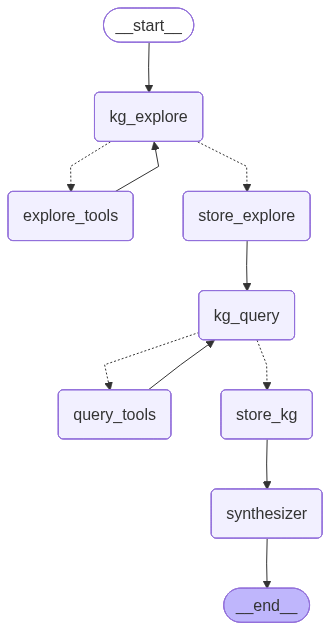

In [7]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

b = StateGraph(AgentState)

b.add_node("kg_explore",      kg_explore_node)
b.add_node("explore_tools",   ToolNode(explore_tools))
b.add_node("store_explore",   store_explore_result)
b.add_node("kg_query",        kg_query_node)
b.add_node("query_tools",     ToolNode(query_tools))
b.add_node("store_kg",        store_kg_result)
b.add_node("synthesizer",     synthesizer_node)

b.add_edge(START, "kg_explore")
b.add_conditional_edges("kg_explore", kg_explore_condition, {"explore_tools":"explore_tools", "store_explore":"store_explore"})
b.add_edge("explore_tools", "kg_explore")
b.add_edge("store_explore", "kg_query")
b.add_conditional_edges("kg_query", kg_query_condition, {"query_tools":"query_tools", "store_kg":"store_kg"})
b.add_edge("query_tools", "kg_query")
b.add_edge("store_kg", "synthesizer")
b.add_edge("synthesizer", END)

react_graph_memory = b.compile(checkpointer=MemorySaver())
display(Image(react_graph_memory.get_graph(xray=True).draw_mermaid_png()))


## 9. Run

In [14]:
from langchain_core.messages import HumanMessage, ToolMessage
from pathlib import Path
import pandas as pd
import json
import re
import time

# -----------------------------------------------------------------------------
# Batch run configuration
# -----------------------------------------------------------------------------
# Put the XLSX file in the same folder as this notebook, or provide an absolute path.
# The file must contain a column named QUESTION_COLUMN.
INPUT_XLSX = "borrajas_test/benchmark_kg_only_prova.xlsx"
QUESTION_COLUMN = "question"
OUTPUT_JSON = "borrajas_test/outputs_kg_only.json"

# Optional: limit the number of rows while testing. Use None to process the whole file.
MAX_ROWS = None

# Optional: choose a stable prefix for LangGraph thread IDs.
THREAD_PREFIX = "borrajas_kg_only"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def parse_final_answer(raw_answer):
    """Parse the synthesizer JSON output, with a fallback for imperfect JSON."""
    if isinstance(raw_answer, dict):
        return raw_answer

    raw_text = str(raw_answer or "").strip()

    try:
        return json.loads(raw_text)
    except Exception:
        pass

    # Fallback: extract the first JSON object if the model wrapped it in text.
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except Exception:
            pass

    return {
        "short_answer": "",
        "answer": raw_text,
        "kg_evidence": "",
        "rag_evidence": "",
        "sources_used": [],
        "confidence": "low",
    }


def row_value(row, column_name, default=""):
    """Return a clean scalar value from a dataframe row."""
    if column_name not in row.index:
        return default
    value = row[column_name]
    if pd.isna(value):
        return default
    return value


def build_initial_state(question):
    """Initial graph state for one question."""
    return {
        "messages": [HumanMessage(content=question)],
        "explore_summary": "",
        "sparql_result": "",
        "final_answer": "",
        "explore_call_count": 0,
        "query_call_count": 0,
    }

def run_one_question(question, row_index):
    """Invoke the compiled graph for one question and return the raw result."""
    config = {
        "configurable": {
            "thread_id": f"{THREAD_PREFIX}_{row_index}"
        }
    }
    return react_graph_memory.invoke(build_initial_state(question), config)


def split_context_units(text):
    """Split retrieved evidence into compact candidate units while preserving SOURCE lines."""
    if not isinstance(text, str) or not text.strip():
        return []

    # Prefer line-level units because retrieved RAG outputs often contain SOURCE/TEXT blocks.
    raw_units = []
    for part in re.split(r"\n+", text):
        part = re.sub(r"\s+", " ", str(part)).strip()
        if part:
            raw_units.append(part)

    # If the text is one long paragraph, add sentence-level units as well.
    if len(raw_units) <= 2:
        raw_units = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s.strip()
        ]

    return raw_units


def normalize_for_overlap(text):
    """Normalize text for simple lexical overlap checks."""
    text = str(text or "").lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def extract_key_terms(*texts):
    """Extract simple answer/question terms used to identify supporting context snippets."""
    stopwords = {
        "the", "a", "an", "and", "or", "of", "in", "on", "to", "from",
        "for", "with", "by", "due", "what", "which", "how", "many",
        "were", "was", "are", "is", "reported", "recorded", "according",
        "information", "answer", "deaths", "death", "fatalities", "fatality"
    }

    terms = set()
    for text in texts:
        norm = normalize_for_overlap(text)
        for token in norm.split():
            if len(token) >= 3 and token not in stopwords:
                terms.add(token)

        # Keep numbers as especially useful anchors.
        for number in re.findall(r"-?\d+(?:\.\d+)?", str(text or "")):
            terms.add(number)

    return terms


def build_supporting_context(question, final, result, max_chars=2000):
    """Build a minimal context snippet used for evaluation.

    The context field should not contain the full input passages. It should contain
    only the smallest available evidence units that support the answer. We first
    search the raw KG/SPARQL and RAG outputs for lines/sentences matching the
    short answer or the question. If no raw supporting unit is found, we fall back
    to the explicit evidence fields produced by the synthesizer.
    """
    short_answer = str(final.get("short_answer", "") or "")
    answer = str(final.get("answer", "") or "")
    kg_evidence = str(final.get("kg_evidence", "") or "")
    rag_evidence = str(final.get("rag_evidence", "") or "")

    kg_context = str(result.get("sparql_result", "") or "")
    rag_context = str(result.get("rag_result", "") or "")

    candidate_text = (
        f"KG/SPARQL result:\n{kg_context}\n\n"
        f"RAG result:\n{rag_context}"
    )
    units = split_context_units(candidate_text)

    key_terms = extract_key_terms(short_answer, question)
    answer_numbers = set(re.findall(r"-?\d+(?:\.\d+)?", short_answer))

    selected = []
    seen = set()

    for unit in units:
        norm = normalize_for_overlap(unit)
        if not norm or norm in seen:
            continue

        unit_tokens = set(norm.split())
        number_hit = bool(answer_numbers and answer_numbers.intersection(unit_tokens))
        lexical_hits = len(key_terms.intersection(unit_tokens))

        # Numbers are strong evidence anchors; otherwise require several lexical overlaps.
        if number_hit or lexical_hits >= 2:
            selected.append(unit)
            seen.add(norm)

        if len("\n".join(selected)) >= max_chars:
            break

    if not selected:
        fallback_parts = []
        if kg_evidence.strip():
            fallback_parts.append("KG evidence: " + kg_evidence.strip())
        if rag_evidence.strip():
            fallback_parts.append("RAG evidence: " + rag_evidence.strip())
        if fallback_parts:
            selected = fallback_parts

    context = "\n".join(selected).strip()
    if len(context) > max_chars:
        context = context[:max_chars].rstrip()
    return context


# -----------------------------------------------------------------------------
# Load questions
# -----------------------------------------------------------------------------
input_path = Path(INPUT_XLSX)
if not input_path.exists():
    raise FileNotFoundError(
        f"Could not find {input_path}. Update INPUT_XLSX with the correct XLSX path."
    )

df = pd.read_excel(input_path)

if QUESTION_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{QUESTION_COLUMN}' was not found. Available columns: {list(df.columns)}"
    )

work_df = df.copy()
work_df = work_df[work_df[QUESTION_COLUMN].notna()].reset_index(drop=False)
work_df = work_df.rename(columns={"index": "source_row_index"})

if MAX_ROWS is not None:
    work_df = work_df.head(MAX_ROWS)

print(f"Loaded {len(work_df)} questions from {input_path} column '{QUESTION_COLUMN}'.")


# -----------------------------------------------------------------------------
# Run graph and collect structured outputs
# -----------------------------------------------------------------------------
records = []

for i, row in work_df.iterrows():
    source_row_index = int(row["source_row_index"])
    question = str(row[QUESTION_COLUMN]).strip()

    if not question:
        continue

    print(f"\n[{i + 1}/{len(work_df)}] {question}")
    start_time = time.time()

    try:
        result = run_one_question(question, source_row_index)
        latency_seconds = round(time.time() - start_time, 3)
        final = parse_final_answer(result.get("final_answer", ""))

        tool_msgs = [m for m in result.get("messages", []) if isinstance(m, ToolMessage)]
        tools_used = [getattr(m, "name", "") for m in tool_msgs]

        # Store only the minimal supporting snippet used to answer the question.
        # Full diagnostic evidence remains available in sparql_result and rag_result.
        context = build_supporting_context(question, final, result)

        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": final.get("short_answer", ""),
            "answer": final.get("answer", ""),
            "context": context,
            "kg_evidence": final.get("kg_evidence", ""),
            "rag_evidence": final.get("rag_evidence", ""),
            "sources_used": final.get("sources_used", []),
            "confidence": final.get("confidence", ""),
            "sparql_result": result.get("sparql_result", ""),
            "rag_result": result.get("rag_result", ""),
            "final_answer_raw": result.get("final_answer", ""),
            "feedback_count": result.get("feedback_count", 0),
            "feedback_result": result.get("feedback_result", ""),
            "tools_used": tools_used,
            "latency_seconds": latency_seconds,
            "status": "ok",
            "error": "",
        }

    except Exception as exc:
        latency_seconds = round(time.time() - start_time, 3)
        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": "",
            "answer": "",
            "context": row_value(row, "context", ""),
            "kg_evidence": "",
            "rag_evidence": "",
            "sources_used": [],
            "confidence": "low",
            "sparql_result": "",
            "rag_result": "",
            "final_answer_raw": "",
            "feedback_count": 0,
            "feedback_result": "",
            "tools_used": [],
            "latency_seconds": latency_seconds,
            "status": "error",
            "error": str(exc),
        }
        print(f"ERROR: {exc}")

    records.append(record)


# -----------------------------------------------------------------------------
# Save JSON output
# -----------------------------------------------------------------------------
output_path = Path(OUTPUT_JSON)
output_path.write_text(
    json.dumps(records, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"\nSaved {len(records)} records to {output_path.resolve()}")

# Display a compact preview.
preview = pd.DataFrame(records)[[
    "source_row_index",
    "question",
    "short_answer",
    "confidence",
    "status",
]]
preview.head()



Loaded 5 questions from borrajas_test/benchmark_kg_only_prova.xlsx column 'question'.

[1/5] How many people were affected by the drought event in Brazil that started in January 2014?
[Explore] deterministic profile completed in 1 pass(es)
[Explore] done in 1 call(s): **KG Exploration Summary – “People affected by the 2014‑January drought in Brazil”**

| Aspect | Det...
[KG Query] done in 1 call(s): The query found a single impact record for the drought event in Brazil that began in January 2014, r...
[Synthesizer] KG-only answer generated

[2/5] Which provinces of Brazil were impacted by the drought that lasted from 2014 to 2016?
[Explore] deterministic profile completed in 1 pass(es)
[Explore] done in 1 call(s): **KG Exploration Summary – Finding Brazilian Provinces (states) hit by the 2014‑2016 drought**

---
...
[KG Query] done in 2 call(s): The query returned no results, likely because the drought subtype filter or exact country URI didn’t...
[Synthesizer] KG-only answer generated

,source_row_index,question,short_answer,confidence,status
0,0,How many people were affected by the drought e...,600,high,ok
1,1,Which provinces of Brazil were impacted by the...,,low,ok
2,2,How many deaths were reported from Storm Desmond?,0,low,ok
3,3,Which administrative districts in England were...,"Cumbria, Lancashire",high,ok
4,4,How many deaths were reported from the flood t...,124,high,ok


In [12]:
print("\n=== CONVERSATION ===")
for m in result["messages"]:
    m.pretty_print()


=== CONVERSATION ===
================================ Human Message =================================

Which country experienced severe winter conditions on January 20, 2017?
================================== Ai Message ==================================

**KG‑Exploration Summary – Finding the country that suffered a “severe winter” on 20 Jan 2017**

| Aspect | What to look for in the graph | Typical URI / literal pattern |
|--------|------------------------------|--------------------------------|
| **Core class** | `https://example.org/clasik#ClimateEvent` (the event you want) | `?e a cl:ClimateEvent` |
| **Date filter** | The event’s start or end date must be *exactly* `2017‑01‑20`. Two predicates can hold a date: <br>• `https://soteria-public.pages.sintef.no/soteria_ontology_documentation#startDate` <br>• `https://soteria-public.pages.sintef.no/soteria_ontology_documentation#endDate` | `?e cl:startDate "2017-01-20"^^xsd:date`  <br>or `?e cl:endDate "2017-01-20"^^xsd:date` |
| **Ph

In [ ]:
from langchain_core.messages import HumanMessage, ToolMessage
from pathlib import Path
import pandas as pd
import json
import re
import time

# -----------------------------------------------------------------------------
# Batch run configuration
# -----------------------------------------------------------------------------
# Put the XLSX file in the same folder as this notebook, or provide an absolute path.
# The file must contain a column named QUESTION_COLUMN.
INPUT_XLSX = "borrajas_test/benchmark_Fernando_only.xlsx"
QUESTION_COLUMN = "question_new"
OUTPUT_JSON = "borrajas_test/outputs_kg_only.json"

# Optional: limit the number of rows while testing. Use None to process the whole file.
MAX_ROWS = None

# Optional: choose a stable prefix for LangGraph thread IDs.
THREAD_PREFIX = "borrajas_kg_only"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def parse_final_answer(raw_answer):
    """Parse the synthesizer JSON output, with a fallback for imperfect JSON."""
    if isinstance(raw_answer, dict):
        return raw_answer

    raw_text = str(raw_answer or "").strip()

    try:
        return json.loads(raw_text)
    except Exception:
        pass

    # Fallback: extract the first JSON object if the model wrapped it in text.
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except Exception:
            pass

    return {
        "short_answer": "",
        "answer": raw_text,
        "kg_evidence": "",
        "rag_evidence": "",
        "sources_used": [],
        "confidence": "low",
    }


def row_value(row, column_name, default=""):
    """Return a clean scalar value from a dataframe row."""
    if column_name not in row.index:
        return default
    value = row[column_name]
    if pd.isna(value):
        return default
    return value


def build_initial_state(question):
    """Initial graph state for one question."""
    return {
        "messages": [HumanMessage(content=question)],
        "explore_summary": "",
        "sparql_result": "",
        "final_answer": "",
        "explore_call_count": 0,
        "query_call_count": 0,
    }

def run_one_question(question, row_index):
    """Invoke the compiled graph for one question and return the raw result."""
    config = {
        "configurable": {
            "thread_id": f"{THREAD_PREFIX}_{row_index}"
        }
    }
    return react_graph_memory.invoke(build_initial_state(question), config)


def split_context_units(text):
    """Split retrieved evidence into compact candidate units while preserving SOURCE lines."""
    if not isinstance(text, str) or not text.strip():
        return []

    # Prefer line-level units because retrieved RAG outputs often contain SOURCE/TEXT blocks.
    raw_units = []
    for part in re.split(r"\n+", text):
        part = re.sub(r"\s+", " ", str(part)).strip()
        if part:
            raw_units.append(part)

    # If the text is one long paragraph, add sentence-level units as well.
    if len(raw_units) <= 2:
        raw_units = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s.strip()
        ]

    return raw_units


def normalize_for_overlap(text):
    """Normalize text for simple lexical overlap checks."""
    text = str(text or "").lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def extract_key_terms(*texts):
    """Extract simple answer/question terms used to identify supporting context snippets."""
    stopwords = {
        "the", "a", "an", "and", "or", "of", "in", "on", "to", "from",
        "for", "with", "by", "due", "what", "which", "how", "many",
        "were", "was", "are", "is", "reported", "recorded", "according",
        "information", "answer", "deaths", "death", "fatalities", "fatality"
    }

    terms = set()
    for text in texts:
        norm = normalize_for_overlap(text)
        for token in norm.split():
            if len(token) >= 3 and token not in stopwords:
                terms.add(token)

        # Keep numbers as especially useful anchors.
        for number in re.findall(r"-?\d+(?:\.\d+)?", str(text or "")):
            terms.add(number)

    return terms


def build_supporting_context(question, final, result, max_chars=2000):
    """Build a minimal context snippet used for evaluation.

    The context field should not contain the full input passages. It should contain
    only the smallest available evidence units that support the answer. We first
    search the raw KG/SPARQL and RAG outputs for lines/sentences matching the
    short answer or the question. If no raw supporting unit is found, we fall back
    to the explicit evidence fields produced by the synthesizer.
    """
    short_answer = str(final.get("short_answer", "") or "")
    answer = str(final.get("answer", "") or "")
    kg_evidence = str(final.get("kg_evidence", "") or "")
    rag_evidence = str(final.get("rag_evidence", "") or "")

    kg_context = str(result.get("sparql_result", "") or "")
    rag_context = str(result.get("rag_result", "") or "")

    candidate_text = (
        f"KG/SPARQL result:\n{kg_context}\n\n"
        f"RAG result:\n{rag_context}"
    )
    units = split_context_units(candidate_text)

    key_terms = extract_key_terms(short_answer, question)
    answer_numbers = set(re.findall(r"-?\d+(?:\.\d+)?", short_answer))

    selected = []
    seen = set()

    for unit in units:
        norm = normalize_for_overlap(unit)
        if not norm or norm in seen:
            continue

        unit_tokens = set(norm.split())
        number_hit = bool(answer_numbers and answer_numbers.intersection(unit_tokens))
        lexical_hits = len(key_terms.intersection(unit_tokens))

        # Numbers are strong evidence anchors; otherwise require several lexical overlaps.
        if number_hit or lexical_hits >= 2:
            selected.append(unit)
            seen.add(norm)

        if len("\n".join(selected)) >= max_chars:
            break

    if not selected:
        fallback_parts = []
        if kg_evidence.strip():
            fallback_parts.append("KG evidence: " + kg_evidence.strip())
        if rag_evidence.strip():
            fallback_parts.append("RAG evidence: " + rag_evidence.strip())
        if fallback_parts:
            selected = fallback_parts

    context = "\n".join(selected).strip()
    if len(context) > max_chars:
        context = context[:max_chars].rstrip()
    return context


# -----------------------------------------------------------------------------
# Load questions
# -----------------------------------------------------------------------------
input_path = Path(INPUT_XLSX)
if not input_path.exists():
    raise FileNotFoundError(
        f"Could not find {input_path}. Update INPUT_XLSX with the correct XLSX path."
    )

df = pd.read_excel(input_path)

if QUESTION_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{QUESTION_COLUMN}' was not found. Available columns: {list(df.columns)}"
    )

work_df = df.copy()
work_df = work_df[work_df[QUESTION_COLUMN].notna()].reset_index(drop=False)
work_df = work_df.rename(columns={"index": "source_row_index"})

if MAX_ROWS is not None:
    work_df = work_df.head(MAX_ROWS)

print(f"Loaded {len(work_df)} questions from {input_path} column '{QUESTION_COLUMN}'.")


# -----------------------------------------------------------------------------
# Run graph and collect structured outputs
# -----------------------------------------------------------------------------
records = []

for i, row in work_df.iterrows():
    source_row_index = int(row["source_row_index"])
    question = str(row[QUESTION_COLUMN]).strip()

    if not question:
        continue

    print(f"\n[{i + 1}/{len(work_df)}] {question}")
    start_time = time.time()

    try:
        result = run_one_question(question, source_row_index)
        latency_seconds = round(time.time() - start_time, 3)
        final = parse_final_answer(result.get("final_answer", ""))

        tool_msgs = [m for m in result.get("messages", []) if isinstance(m, ToolMessage)]
        tools_used = [getattr(m, "name", "") for m in tool_msgs]

        # Store only the minimal supporting snippet used to answer the question.
        # Full diagnostic evidence remains available in sparql_result and rag_result.
        context = build_supporting_context(question, final, result)

        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": final.get("short_answer", ""),
            "answer": final.get("answer", ""),
            "context": context,
            "kg_evidence": final.get("kg_evidence", ""),
            "rag_evidence": final.get("rag_evidence", ""),
            "sources_used": final.get("sources_used", []),
            "confidence": final.get("confidence", ""),
            "sparql_result": result.get("sparql_result", ""),
            "rag_result": result.get("rag_result", ""),
            "final_answer_raw": result.get("final_answer", ""),
            "feedback_count": result.get("feedback_count", 0),
            "feedback_result": result.get("feedback_result", ""),
            "tools_used": tools_used,
            "latency_seconds": latency_seconds,
            "status": "ok",
            "error": "",
        }

    except Exception as exc:
        latency_seconds = round(time.time() - start_time, 3)
        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": "",
            "answer": "",
            "context": row_value(row, "context", ""),
            "kg_evidence": "",
            "rag_evidence": "",
            "sources_used": [],
            "confidence": "low",
            "sparql_result": "",
            "rag_result": "",
            "final_answer_raw": "",
            "feedback_count": 0,
            "feedback_result": "",
            "tools_used": [],
            "latency_seconds": latency_seconds,
            "status": "error",
            "error": str(exc),
        }
        print(f"ERROR: {exc}")

    records.append(record)


# -----------------------------------------------------------------------------
# Save JSON output
# -----------------------------------------------------------------------------
output_path = Path(OUTPUT_JSON)
output_path.write_text(
    json.dumps(records, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"\nSaved {len(records)} records to {output_path.resolve()}")

# Display a compact preview.
preview = pd.DataFrame(records)[[
    "source_row_index",
    "question",
    "short_answer",
    "confidence",
    "status",
]]
preview.head()



In [ ]:
from langchain_core.messages import HumanMessage, ToolMessage
from pathlib import Path
import pandas as pd
import json
import re
import time

# -----------------------------------------------------------------------------
# Batch run configuration
# -----------------------------------------------------------------------------
# Put the XLSX file in the same folder as this notebook, or provide an absolute path.
# The file must contain a column named QUESTION_COLUMN.
INPUT_XLSX = "borrajas_test/benchmark_Fernando_only.xlsx"
QUESTION_COLUMN = "question_new"
OUTPUT_JSON = "borrajas_test/outputs_kg_only_2.json"

# Optional: limit the number of rows while testing. Use None to process the whole file.
MAX_ROWS = None

# Optional: choose a stable prefix for LangGraph thread IDs.
THREAD_PREFIX = "borrajas_kg_only"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def parse_final_answer(raw_answer):
    """Parse the synthesizer JSON output, with a fallback for imperfect JSON."""
    if isinstance(raw_answer, dict):
        return raw_answer

    raw_text = str(raw_answer or "").strip()

    try:
        return json.loads(raw_text)
    except Exception:
        pass

    # Fallback: extract the first JSON object if the model wrapped it in text.
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except Exception:
            pass

    return {
        "short_answer": "",
        "answer": raw_text,
        "kg_evidence": "",
        "rag_evidence": "",
        "sources_used": [],
        "confidence": "low",
    }


def row_value(row, column_name, default=""):
    """Return a clean scalar value from a dataframe row."""
    if column_name not in row.index:
        return default
    value = row[column_name]
    if pd.isna(value):
        return default
    return value


def build_initial_state(question):
    """Initial graph state for one question."""
    return {
        "messages": [HumanMessage(content=question)],
        "explore_summary": "",
        "sparql_result": "",
        "final_answer": "",
        "explore_call_count": 0,
        "query_call_count": 0,
    }

def run_one_question(question, row_index):
    """Invoke the compiled graph for one question and return the raw result."""
    config = {
        "configurable": {
            "thread_id": f"{THREAD_PREFIX}_{row_index}"
        }
    }
    return react_graph_memory.invoke(build_initial_state(question), config)


def split_context_units(text):
    """Split retrieved evidence into compact candidate units while preserving SOURCE lines."""
    if not isinstance(text, str) or not text.strip():
        return []

    # Prefer line-level units because retrieved RAG outputs often contain SOURCE/TEXT blocks.
    raw_units = []
    for part in re.split(r"\n+", text):
        part = re.sub(r"\s+", " ", str(part)).strip()
        if part:
            raw_units.append(part)

    # If the text is one long paragraph, add sentence-level units as well.
    if len(raw_units) <= 2:
        raw_units = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s.strip()
        ]

    return raw_units


def normalize_for_overlap(text):
    """Normalize text for simple lexical overlap checks."""
    text = str(text or "").lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def extract_key_terms(*texts):
    """Extract simple answer/question terms used to identify supporting context snippets."""
    stopwords = {
        "the", "a", "an", "and", "or", "of", "in", "on", "to", "from",
        "for", "with", "by", "due", "what", "which", "how", "many",
        "were", "was", "are", "is", "reported", "recorded", "according",
        "information", "answer", "deaths", "death", "fatalities", "fatality"
    }

    terms = set()
    for text in texts:
        norm = normalize_for_overlap(text)
        for token in norm.split():
            if len(token) >= 3 and token not in stopwords:
                terms.add(token)

        # Keep numbers as especially useful anchors.
        for number in re.findall(r"-?\d+(?:\.\d+)?", str(text or "")):
            terms.add(number)

    return terms


def build_supporting_context(question, final, result, max_chars=2000):
    """Build a minimal context snippet used for evaluation.

    The context field should not contain the full input passages. It should contain
    only the smallest available evidence units that support the answer. We first
    search the raw KG/SPARQL and RAG outputs for lines/sentences matching the
    short answer or the question. If no raw supporting unit is found, we fall back
    to the explicit evidence fields produced by the synthesizer.
    """
    short_answer = str(final.get("short_answer", "") or "")
    answer = str(final.get("answer", "") or "")
    kg_evidence = str(final.get("kg_evidence", "") or "")
    rag_evidence = str(final.get("rag_evidence", "") or "")

    kg_context = str(result.get("sparql_result", "") or "")
    rag_context = str(result.get("rag_result", "") or "")

    candidate_text = (
        f"KG/SPARQL result:\n{kg_context}\n\n"
        f"RAG result:\n{rag_context}"
    )
    units = split_context_units(candidate_text)

    key_terms = extract_key_terms(short_answer, question)
    answer_numbers = set(re.findall(r"-?\d+(?:\.\d+)?", short_answer))

    selected = []
    seen = set()

    for unit in units:
        norm = normalize_for_overlap(unit)
        if not norm or norm in seen:
            continue

        unit_tokens = set(norm.split())
        number_hit = bool(answer_numbers and answer_numbers.intersection(unit_tokens))
        lexical_hits = len(key_terms.intersection(unit_tokens))

        # Numbers are strong evidence anchors; otherwise require several lexical overlaps.
        if number_hit or lexical_hits >= 2:
            selected.append(unit)
            seen.add(norm)

        if len("\n".join(selected)) >= max_chars:
            break

    if not selected:
        fallback_parts = []
        if kg_evidence.strip():
            fallback_parts.append("KG evidence: " + kg_evidence.strip())
        if rag_evidence.strip():
            fallback_parts.append("RAG evidence: " + rag_evidence.strip())
        if fallback_parts:
            selected = fallback_parts

    context = "\n".join(selected).strip()
    if len(context) > max_chars:
        context = context[:max_chars].rstrip()
    return context


# -----------------------------------------------------------------------------
# Load questions
# -----------------------------------------------------------------------------
input_path = Path(INPUT_XLSX)
if not input_path.exists():
    raise FileNotFoundError(
        f"Could not find {input_path}. Update INPUT_XLSX with the correct XLSX path."
    )

df = pd.read_excel(input_path)

if QUESTION_COLUMN not in df.columns:
    raise ValueError(
        f"Column '{QUESTION_COLUMN}' was not found. Available columns: {list(df.columns)}"
    )

work_df = df.copy()
work_df = work_df[work_df[QUESTION_COLUMN].notna()].reset_index(drop=False)
work_df = work_df.rename(columns={"index": "source_row_index"})

if MAX_ROWS is not None:
    work_df = work_df.head(MAX_ROWS)

print(f"Loaded {len(work_df)} questions from {input_path} column '{QUESTION_COLUMN}'.")


# -----------------------------------------------------------------------------
# Run graph and collect structured outputs
# -----------------------------------------------------------------------------
records = []

for i, row in work_df.iterrows():
    source_row_index = int(row["source_row_index"])
    question = str(row[QUESTION_COLUMN]).strip()

    if not question:
        continue

    print(f"\n[{i + 1}/{len(work_df)}] {question}")
    start_time = time.time()

    try:
        result = run_one_question(question, source_row_index)
        latency_seconds = round(time.time() - start_time, 3)
        final = parse_final_answer(result.get("final_answer", ""))

        tool_msgs = [m for m in result.get("messages", []) if isinstance(m, ToolMessage)]
        tools_used = [getattr(m, "name", "") for m in tool_msgs]

        # Store only the minimal supporting snippet used to answer the question.
        # Full diagnostic evidence remains available in sparql_result and rag_result.
        context = build_supporting_context(question, final, result)

        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": final.get("short_answer", ""),
            "answer": final.get("answer", ""),
            "context": context,
            "kg_evidence": final.get("kg_evidence", ""),
            "rag_evidence": final.get("rag_evidence", ""),
            "sources_used": final.get("sources_used", []),
            "confidence": final.get("confidence", ""),
            "sparql_result": result.get("sparql_result", ""),
            "rag_result": result.get("rag_result", ""),
            "final_answer_raw": result.get("final_answer", ""),
            "feedback_count": result.get("feedback_count", 0),
            "feedback_result": result.get("feedback_result", ""),
            "tools_used": tools_used,
            "latency_seconds": latency_seconds,
            "status": "ok",
            "error": "",
        }

    except Exception as exc:
        latency_seconds = round(time.time() - start_time, 3)
        record = {
            "source_row_index": source_row_index,
            "question": question,
            "short_answer": "",
            "answer": "",
            "context": row_value(row, "context", ""),
            "kg_evidence": "",
            "rag_evidence": "",
            "sources_used": [],
            "confidence": "low",
            "sparql_result": "",
            "rag_result": "",
            "final_answer_raw": "",
            "feedback_count": 0,
            "feedback_result": "",
            "tools_used": [],
            "latency_seconds": latency_seconds,
            "status": "error",
            "error": str(exc),
        }
        print(f"ERROR: {exc}")

    records.append(record)


# -----------------------------------------------------------------------------
# Save JSON output
# -----------------------------------------------------------------------------
output_path = Path(OUTPUT_JSON)
output_path.write_text(
    json.dumps(records, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"\nSaved {len(records)} records to {output_path.resolve()}")

# Display a compact preview.
preview = pd.DataFrame(records)[[
    "source_row_index",
    "question",
    "short_answer",
    "confidence",
    "status",
]]
preview.head()

